In [2]:
# Init the environment
import sys
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
sys.path.insert(0, "../..")

from init_physics_env import *

## IQB 2018

### 1.
$$ f(x) := -x^3 + 3x^2 - 2x $$

#### a.
$$
\begin{align*}
f'(x) &= -3x^2 + 6x - 2 \\
f'(1) &= -3 + 6 - 2 \\
&= 1
\end{align*}
$$

#### b.
$$
\begin{align*}
x_W &:= 1 \\
y_W &= f(x_W) \\
&= 0 \\
g: y &= mx - m~,\, m\in\mathbb R^+ \\
f(x) &= y_g \\
-x^3 + 3x^2 - 2x &= mx \\
x(x^2 + 2x + 2+m) &= 0 \\
\rightarrow 
\end{align*}
$$

## IQB 2025 B-Teil Analysis

### 1.
$$
\begin{align*}
f_b(x) &:= \frac1{16}x^2e^{-bx+4b} ~,\,b \in\mathbb R^+
\end{align*}
$$

In [3]:
x, y, b = symbols("x y b", real=True)

f = Rational(1,16)*x**2*(E**(-b*x + 4*b))

#### a.
$$
\begin{align*}
\lim_{x\to-\infty} f_b(x) &= \infty \\
\lim_{x\to\infty} f_b(x) &= 0 \\
f_b(4) &= \frac1{16}\cdot 4^2 \cdot e^{-b\cdot 4 + 4b} \\
&= 1 \cdot e^0 \\
&= 1
\end{align*}
$$

#### b.
$$
\begin{align*}
f'_b(x) &= 0
\end{align*}
$$

In [8]:
sols = solve(diff(f, x), x)
sols

$$
\begin{align*}
\rightarrow x &\in \left\{0; \frac2b\right\} \\
\end{align*}
$$

In [11]:
extreme_coords = [diff(f,x,x).subs(x, s).simplify() for s in sols]

(
    Eq(Symbol("x_0"), extreme_coords[0]),
    Eq(Symbol("x_1"), extreme_coords[1]),
)

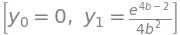

In [13]:
extreme_ys = [f.subs(x, e).simplify() for e in sols]

[Eq(Symbol(f"y_{i}"), e) for i, e in enumerate(extreme_ys)]

$$
\begin{align*}
f''_b(x_0) &= \frac{e^{4b}}{8} \\
&> 0 \\
&\rightarrow \text{Tiefpunkt} \\
f''_b(x_1) &= -\frac{e^{4b-2}}{8} \\
&< 0 \\
&\rightarrow \text{Hochpunkt} \\
T&(0|0) \\
H&\left( \frac2b\middle| \frac{e^{4b-2}}{4b^2} \right)
\end{align*}
$$

$$
\begin{align*}
d^2(b) &= \left( \frac2b \right)^2 + \left( \frac{e^{4b-2}}{4b^2} \right)^2 \\
d^2(b) &= 36
\end{align*}
$$

In [33]:
[
    nsolve((2/x)**2 + (E**(4*x-2)/(4*x**2))**2 - 36, x, 0.1),
    nsolve((2/x)**2 + (E**(4*x-2)/(4*x**2))**2 - 36, x, 1)
]

### 2.
$$
\begin{align*}
r(x) &:= \frac1{16}x^2 e^{-0,25x + 1}
\end{align*}
$$

In [34]:
r = Rational(1,16)*x**2*E**(-Rational(1,4)*x+1)

#### a.
$$
\begin{align*}
h_S &= r(-4) \\
h_E &= r(10)
\end{align*}
$$

In [36]:
hs = r.subs(x,-4).simplify()
he = r.subs(x,10).simplify()

(
    Eq(Symbol("h_S"), hs).evalf(),
    Eq(Symbol("h_E"), he).evalf()
)

Die Höhe des Startpodests entspricht ca. $\displaystyle 7,39 \text{ m} $ und die Höhe des Endpunktes ist rund $\displaystyle 1,39 \text{ m} $.


#### b.
$$
\begin{align*}
r'(-4) &= \tan \alpha ~,\, \alpha \in]-90^\circ; 0^\circ[ \\
\beta &= 180^\circ - \left| \alpha \right| \\
&= 180^\circ + \alpha
\end{align*}
$$

Der Winkel $\beta$ entspricht im Sachzusammenhang näherungsweise dem Winkel zwischen dem horizontalen Startpodest und dem Anfang der Strecke der Rutsche.

#### c.
$$
\begin{align*}
r(x) &= 0,05
\end{align*}
$$

In [42]:
negsol = nsolve(r - Rational(5,100), x, -0.5)
possol = nsolve(r - Rational(5,100), x, 0.5)
(
    Eq(Symbol("x_0"), negsol),
    Eq(Symbol("x_1"), possol)
)

$$ V = 1,5 \cdot \int_{x_0}^{x_1}\left( 0,05 - r(x) \right)dx $$

In [43]:
Eq(Symbol("V"), Rational(3,2)*Integral((Rational(5,100) - r), [x, negsol, possol]).doit())

Das Volumen des Wassers in der Mulde beträgt ca. $\displaystyle 0,0545 \text{ m}^3 $ bzw. $\displaystyle 54,5 \text{ l} $.

#### d.
